# Coca-Cola (KO) End-to-End EDA, Statistical Analysis, and Data Storytelling

## Project Goal
Build a complete, real-world Exploratory Data Analysis (EDA) workflow for `KO.csv` to understand market behavior, identify risks/opportunities, and derive actionable business and modeling insights.

## What this notebook covers
- Data loading, quality checks, and preprocessing best practices
- Data understanding: composition, distribution, comparison, and relationships
- Patterns, trends, outliers, and regime behavior
- Statistical analysis for normality, stationarity, and distribution shape
- Animated EDA with Plotly and publication-quality Seaborn charts
- Professional interactive dashboard in notebook
- Storytelling: root problem, cause -> failure -> outcome mapping
- Solution roadmap, before vs after mapping, measurable impact, and final conclusion

In [12]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from statsmodels.tsa.stattools import adfuller

from IPython.display import display, Markdown

# Visual style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries loaded. Ready for EDA.")

Libraries loaded. Ready for EDA.


## Reusable EDA Functions

The notebook uses modular functions so each step is auditable, reusable, and easy to explain in real projects.

In [13]:
def load_data(path: str) -> pd.DataFrame:
    """Load CSV safely and standardize column names."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df


def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Apply essential preprocessing for time-series EDA and modeling."""
    data = df.copy()

    # Parse date and sort chronologically to prevent leakage in downstream work.
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data = data.sort_values("Date").reset_index(drop=True)

    # Remove duplicate dates (keep latest row if duplicates exist).
    data = data.drop_duplicates(subset=["Date"], keep="last")

    # Ensure numeric columns are truly numeric.
    numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Core derived features used in finance EDA.
    data["Return"] = data["Close"].pct_change()
    data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))
    data["Range"] = data["High"] - data["Low"]
    data["Body"] = (data["Close"] - data["Open"]).abs()
    data["Direction"] = np.where(data["Close"] >= data["Open"], "Up", "Down")

    # Rolling market behavior features.
    data["MA_20"] = data["Close"].rolling(20).mean()
    data["MA_50"] = data["Close"].rolling(50).mean()
    data["Volatility_20"] = data["Return"].rolling(20).std() * np.sqrt(252)

    # Date breakdown for storytelling and grouped analysis.
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Month_Name"] = data["Date"].dt.strftime("%b")
    data["Quarter"] = data["Date"].dt.to_period("Q").astype(str)

    return data


def quality_report(df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact data-quality report."""
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(3),
        "n_unique": df.nunique(dropna=True),
    })
    return report.sort_values(["missing_count", "n_unique"], ascending=[False, False])


def summary_statistics(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Extended descriptive statistics for selected numeric columns."""
    desc = df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    desc["skew"] = df[cols].skew()
    desc["kurtosis"] = df[cols].kurtosis()
    return desc


def iqr_outlier_flags(series: pd.Series) -> pd.Series:
    """Identify outliers using the IQR rule (robust to non-normal data)."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)


def run_statistical_tests(data: pd.DataFrame) -> pd.DataFrame:
    """Run key statistical tests for financial time-series diagnostics."""
    r = data["Return"].dropna()

    # Normality test
    jb_stat, jb_p = stats.jarque_bera(r)

    # Stationarity test
    adf_stat, adf_p, _, _, _, _ = adfuller(r)

    # One-sample t-test: is mean return statistically different from 0?
    t_stat, t_p = stats.ttest_1samp(r, popmean=0.0)

    results = pd.DataFrame({
        "Test": ["Jarque-Bera (normality)", "ADF (stationarity)", "One-sample t-test (mean return=0)"],
        "Statistic": [jb_stat, adf_stat, t_stat],
        "P_Value": [jb_p, adf_p, t_p],
        "Interpretation_Rule": [
            "p<0.05 => reject normality",
            "p<0.05 => stationary series",
            "p<0.05 => mean return differs from 0",
        ],
    })
    return results

## Function-by-Function Summary

- `load_data(path)`: reads CSV and standardizes column names.
- `preprocess_data(df)`: performs date parsing, sorting, de-duplication, numeric coercion, and feature engineering.
- `quality_report(df)`: builds a compact quality table (type, missingness, cardinality).
- `summary_statistics(df, cols)`: creates robust descriptive stats including skewness and kurtosis.
- `iqr_outlier_flags(series)`: flags potential outliers using IQR.
- `run_statistical_tests(data)`: runs Jarque-Bera, ADF, and one-sample t-test for finance diagnostics.

In [14]:
# Load and preprocess
raw_df = load_data("KO.csv")
df = preprocess_data(raw_df)

print(f"Raw shape: {raw_df.shape}")
print(f"Processed shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

# Quick first look
display(df.head(3))
display(df.tail(3))

# Data quality report
dq = quality_report(df)
display(dq)

Raw shape: (6559, 6)
Processed shape: (6559, 18)
Date range: 2000-01-03 -> 2026-01-30


,Date,Close,High,Low,Open,Volume,Return,Log_Return,Range,Body,Direction,MA_20,MA_50,Volatility_20,Year,Month,Month_Name,Quarter
0,2000-01-03,13.6150,14.0074,13.3433,14.0074,10997000,NaN,NaN,0.6641,0.3924,Down,NaN,NaN,NaN,2000,1,Jan,2000Q1
1,2000-01-04,13.6300,13.7206,13.4338,13.6150,7308000,0.0011,0.0011,0.2868,0.0151,Up,NaN,NaN,NaN,2000,1,Jan,2000Q1
2,2000-01-05,13.7508,13.8716,13.5395,13.6300,9457400,0.0089,0.0088,0.3321,0.1208,Up,NaN,NaN,NaN,2000,1,Jan,2000Q1


,Date,Close,High,Low,Open,Volume,Return,Log_Return,Range,Body,Direction,MA_20,MA_50,Volatility_20,Year,Month,Month_Name,Quarter
6556,2026-01-28,73.0600,73.6200,72.5700,73.2100,14633700,-0.0067,-0.0067,1.0500,0.1500,Down,70.7040,70.7060,0.1811,2026,1,Jan,2026Q1
6557,2026-01-29,73.4300,74.0900,73.1400,73.1800,20862100,0.0051,0.0051,0.9500,0.2500,Up,70.8720,70.7614,0.1810,2026,1,Jan,2026Q1
6558,2026-01-30,74.8100,74.9000,73.5400,73.7100,26420500,0.0188,0.0186,1.3600,1.1000,Up,71.1170,70.8538,0.1890,2026,1,Jan,2026Q1


,dtype,missing_count,missing_pct,n_unique
MA_50,float64,49,0.7470,6509
Volatility_20,float64,20,0.3050,6538
MA_20,float64,19,0.2900,6529
Return,float64,1,0.0150,6483
Log_Return,float64,1,0.0150,6483
Date,datetime64[ns],0,0.0000,6559
Open,float64,0,0.0000,6550
Low,float64,0,0.0000,6544
High,float64,0,0.0000,6542
Range,float64,0,0.0000,6488


## A) Understanding Data: Composition

This section answers:
- What variables exist and what do they represent?
- What is the time coverage and granularity?
- Is data quality strong enough for analysis/modeling?

In [15]:
numeric_cols = ["Open", "High", "Low", "Close", "Volume", "Return", "Log_Return", "Range", "Body", "Volatility_20"]
stats_table = summary_statistics(df, numeric_cols)
display(stats_table)

# Composition by direction and calendar
composition_direction = df["Direction"].value_counts(normalize=True).mul(100).round(2).rename("pct")
composition_year = df.groupby("Year").size().rename("trading_days")

display(composition_direction)
display(composition_year.tail(10))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
Open,"6,559.0000",29.0279,17.1978,9.4321,10.4836,11.2283,13.4122,25.5641,39.6455,62.0078,70.2240,73.7100,0.7972,-0.4808
High,"6,559.0000",29.2366,17.3044,9.5592,10.5437,11.3245,13.5396,25.7253,39.9248,62.3850,70.6772,74.9000,0.7994,-0.4771
Low,"6,559.0000",28.8128,17.0849,9.4092,10.3848,11.1352,13.2812,25.3601,39.2465,61.5467,69.7589,73.5400,0.7944,-0.4844
Close,"6,559.0000",29.0323,17.1984,9.4245,10.4802,11.2359,13.4183,25.5458,39.5399,62.0421,70.2277,74.8100,0.7980,-0.4776
Volume,"6,559.0000","14,829,142.5980","7,290,517.6719","2,147,400.0000","5,262,952.0000","7,094,840.0000","10,160,450.0000","13,236,400.0000","17,404,950.0000","27,937,160.0000","40,838,868.0000","124,169,000.0000",2.7345,17.6327
Return,"6,558.0000",0.0003,0.0128,-0.1006,-0.0348,-0.0187,-0.0055,0.0004,0.0062,0.0187,0.0372,0.1388,0.0305,9.4398
Log_Return,"6,558.0000",0.0003,0.0128,-0.1060,-0.0354,-0.0189,-0.0055,0.0004,0.0062,0.0186,0.0366,0.1300,-0.1870,9.2823
Range,"6,559.0000",0.4237,0.3470,0.0463,0.0807,0.1127,0.2036,0.3165,0.5333,1.0644,1.7288,5.6309,3.0065,18.6184
Body,"6,559.0000",0.2041,0.2453,0.0000,0.0000,0.0107,0.0537,0.1265,0.2654,0.6573,1.1385,3.7738,3.5109,22.4047
Volatility_20,"6,539.0000",0.1764,0.1030,0.0510,0.0630,0.0777,0.1145,0.1486,0.2034,0.3617,0.5954,0.8831,2.6822,10.5354


Direction
Up     52.2200
Down   47.7800
Name: pct, dtype: float64

Year
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023    250
2024    252
2025    250
2026     20
Name: trading_days, dtype: int64

## B) Distribution Analysis

Goal: inspect central tendency, spread, skewness, fat tails, and potential abnormal behavior.

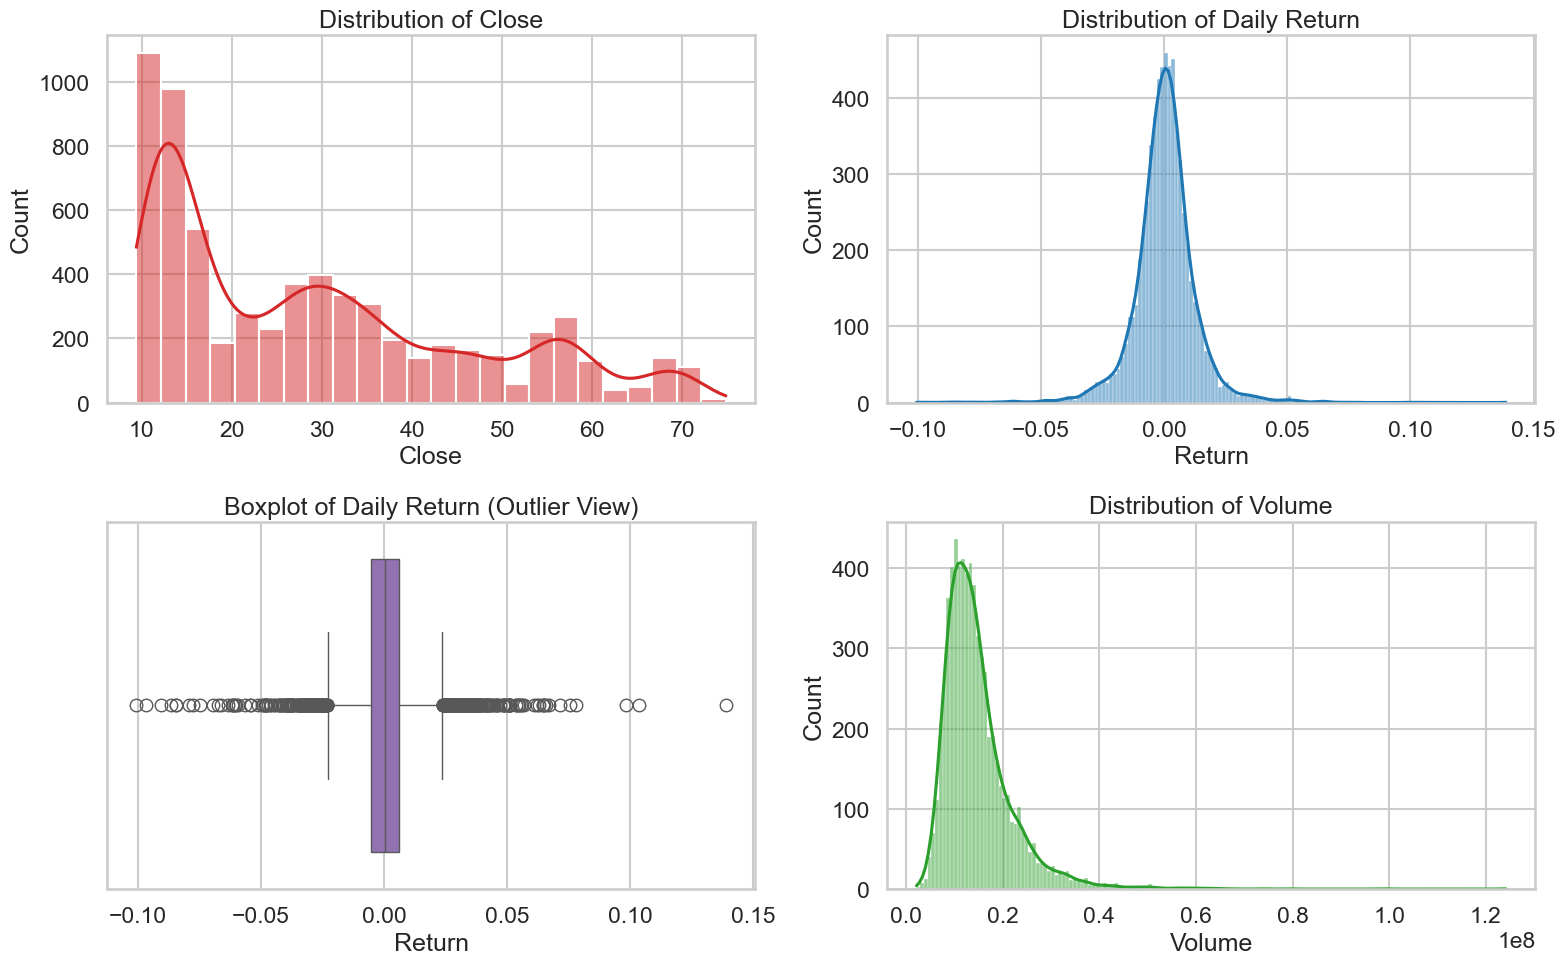

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["Close"], kde=True, ax=axes[0, 0], color="#d62728")
axes[0, 0].set_title("Distribution of Close")

sns.histplot(df["Return"].dropna(), kde=True, ax=axes[0, 1], color="#1f77b4")
axes[0, 1].set_title("Distribution of Daily Return")

sns.boxplot(x=df["Return"], ax=axes[1, 0], color="#9467bd")
axes[1, 0].set_title("Boxplot of Daily Return (Outlier View)")

sns.histplot(df["Volume"], kde=True, ax=axes[1, 1], color="#2ca02c")
axes[1, 1].set_title("Distribution of Volume")

plt.tight_layout()
plt.show()

## C) Comparison and Relationship Analysis

Goal: quantify how variables move together and where nonlinear effects may exist.

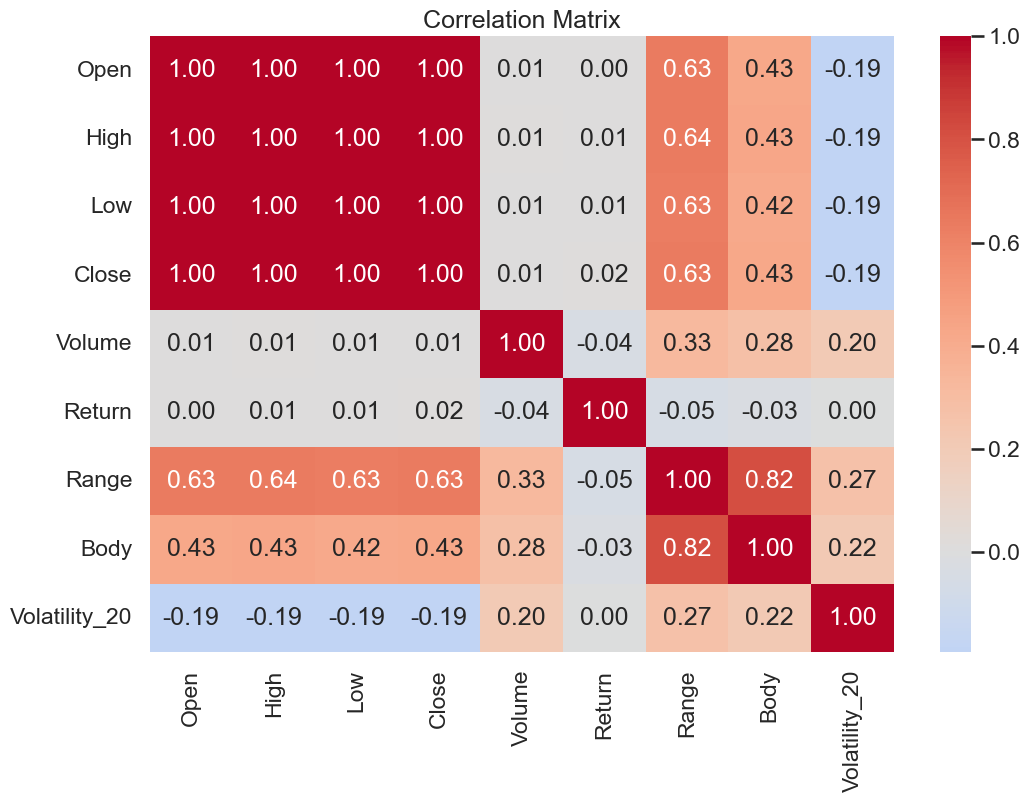

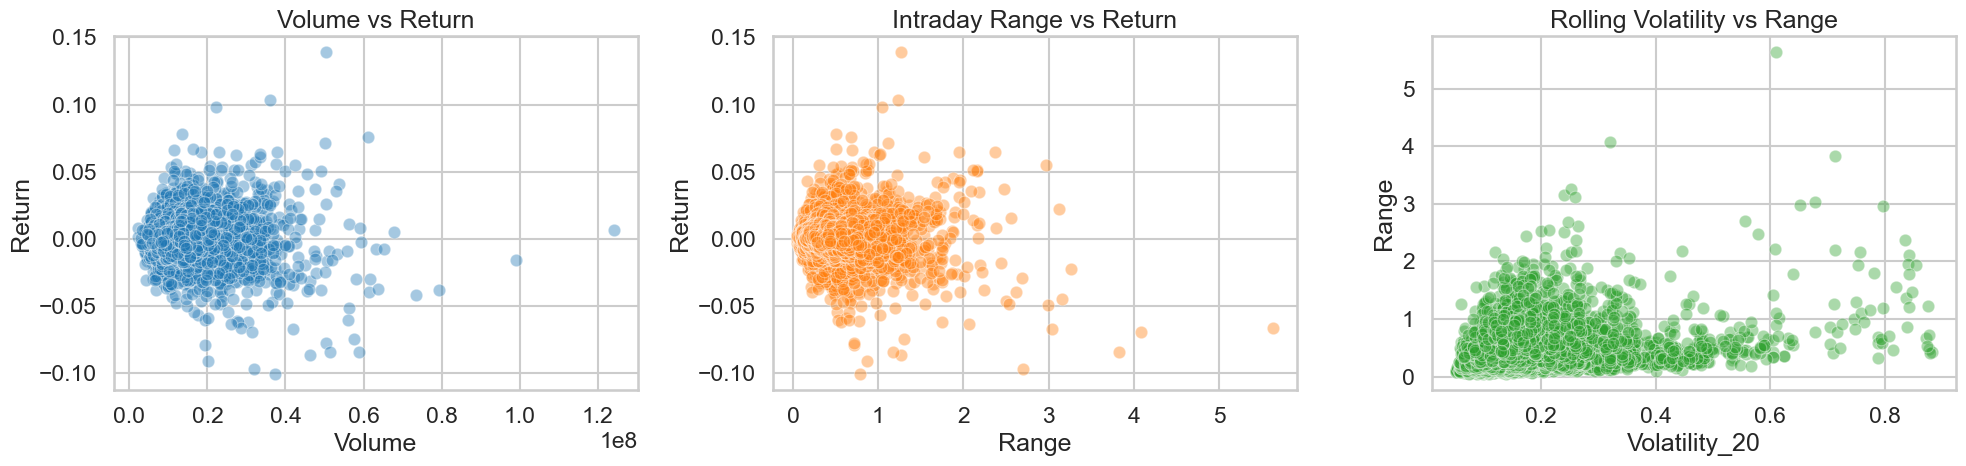

In [17]:
corr_cols = ["Open", "High", "Low", "Close", "Volume", "Return", "Range", "Body", "Volatility_20"]
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

# Relationships
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(data=df, x="Volume", y="Return", alpha=0.4, ax=axes[0], color="#1f77b4")
axes[0].set_title("Volume vs Return")

sns.scatterplot(data=df, x="Range", y="Return", alpha=0.4, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Intraday Range vs Return")

sns.scatterplot(data=df, x="Volatility_20", y="Range", alpha=0.4, ax=axes[2], color="#2ca02c")
axes[2].set_title("Rolling Volatility vs Range")

plt.tight_layout()
plt.show()

## D) Patterns, Trends, and Regime Behavior

Focus:
- long-term trend
- moving-average structure
- volatility cycles
- seasonality (monthly tendency)

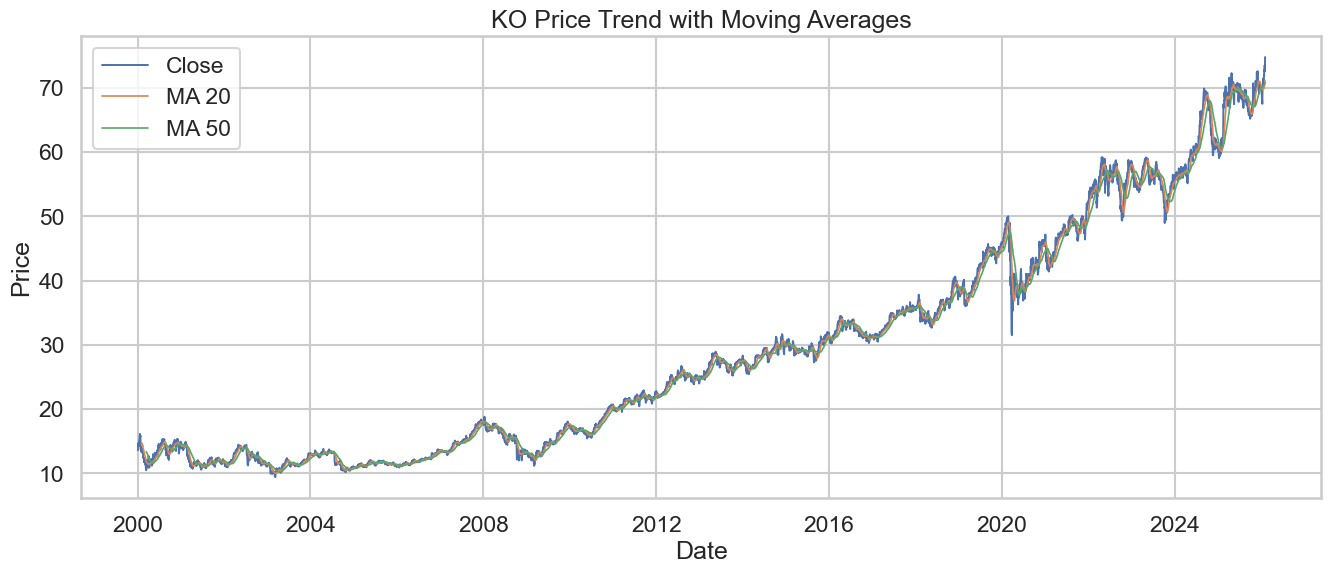

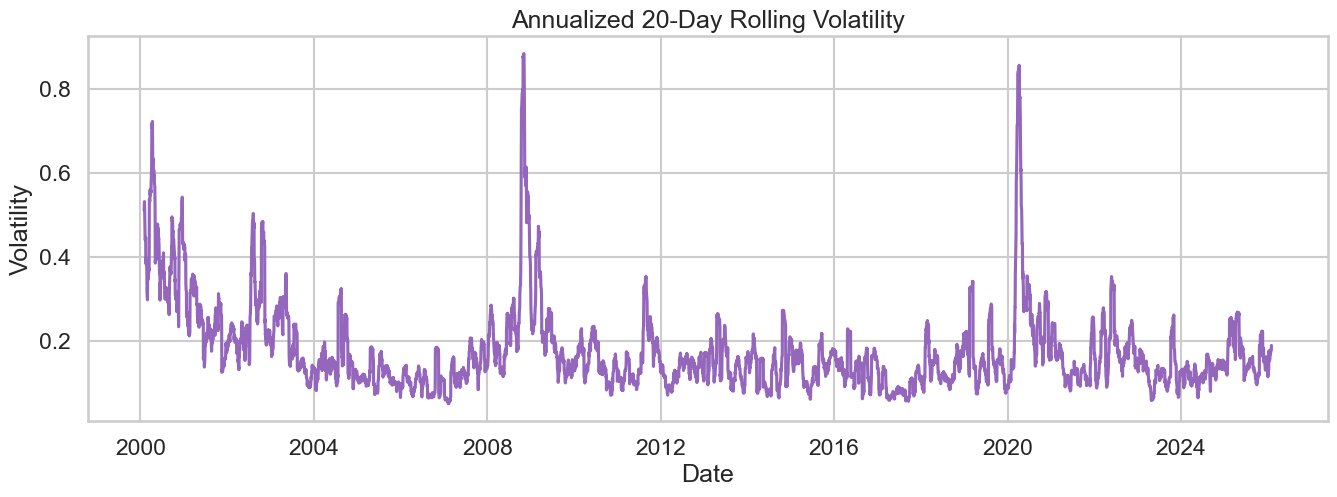

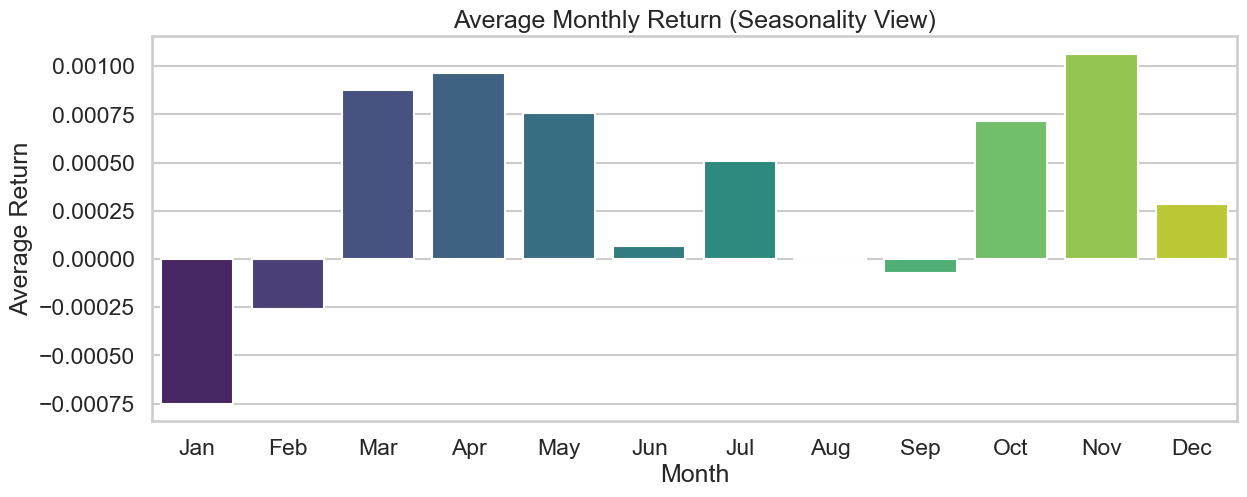

In [18]:
# Trend with moving averages
plt.figure(figsize=(16, 6))
plt.plot(df["Date"], df["Close"], label="Close", linewidth=1.4)
plt.plot(df["Date"], df["MA_20"], label="MA 20", linewidth=1.2)
plt.plot(df["Date"], df["MA_50"], label="MA 50", linewidth=1.2)
plt.title("KO Price Trend with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Volatility regime behavior
plt.figure(figsize=(16, 5))
plt.plot(df["Date"], df["Volatility_20"], color="#9467bd")
plt.title("Annualized 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

# Monthly seasonality profile
df_monthly = (
    df.groupby(["Year", "Month"], as_index=False)
      .agg(Close=("Close", "last"), Return=("Return", "mean"), Volume=("Volume", "mean"))
)

df_monthly["Month_Name"] = pd.to_datetime(df_monthly["Month"], format="%m").dt.strftime("%b")
seasonality = df_monthly.groupby("Month_Name", as_index=False)["Return"].mean()
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
seasonality["Month_Name"] = pd.Categorical(seasonality["Month_Name"], categories=month_order, ordered=True)
seasonality = seasonality.sort_values("Month_Name")

plt.figure(figsize=(14, 5))
sns.barplot(data=seasonality, x="Month_Name", y="Return", palette="viridis")
plt.title("Average Monthly Return (Seasonality View)")
plt.xlabel("Month")
plt.ylabel("Average Return")
plt.xticks(rotation=0)
plt.show()

## E) Outliers and Risk Events

Outliers in returns and volume often indicate event-driven market stress (macro news, earnings surprises, policy shocks).

In [19]:
# Outlier flags
return_outliers = iqr_outlier_flags(df["Return"].dropna())
volume_outliers = iqr_outlier_flags(df["Volume"].dropna())

return_outlier_count = int(return_outliers.sum())
volume_outlier_count = int(volume_outliers.sum())

print(f"Return outliers (IQR): {return_outlier_count}")
print(f"Volume outliers (IQR): {volume_outlier_count}")

# Top absolute return shock days
shock_days = df.assign(abs_return=df["Return"].abs()).nlargest(10, "abs_return")
display(shock_days[["Date", "Open", "High", "Low", "Close", "Volume", "Return", "Volatility_20"]])

Return outliers (IQR): 415
Volume outliers (IQR): 314


,Date,Open,High,Low,Close,Volume,Return,Volatility_20
2207,2008-10-13,12.7201,13.9209,12.6557,13.8419,50478400,0.1388,0.7118
2218,2008-10-28,12.1724,13.2737,12.0435,13.2531,36079600,0.1034,0.8765
699,2002-10-16,12.6554,12.6554,11.8657,11.9467,37382000,-0.1006,0.4707
50,2000-03-15,10.5449,11.5904,10.5449,11.5297,22138200,0.0981,0.5182
5079,2020-03-12,40.3795,41.5358,38.8405,39.2315,31913100,-0.0967,0.5552
65,2000-04-05,12.3479,12.3479,11.4843,11.5449,20256600,-0.0907,0.7044
2205,2008-10-09,13.9327,13.9502,12.6820,12.6820,46288400,-0.0867,0.4577
5085,2020-03-20,35.2034,35.3041,31.4775,32.1404,51513500,-0.0844,0.7132
4809,2019-02-14,37.6557,37.8653,36.6881,36.7606,58905400,-0.0844,0.3261
224,2000-11-20,14.3639,14.3639,13.6473,13.7997,19313200,-0.0793,0.3815


## F) Statistical Analysis

This section validates assumptions used in modeling and risk analytics.

In [20]:
test_results = run_statistical_tests(df)
display(test_results)

# Additional reference metrics
annual_return = (1 + df["Return"].dropna().mean()) ** 252 - 1
annual_vol = df["Return"].dropna().std() * np.sqrt(252)
sharpe_like = annual_return / annual_vol if annual_vol != 0 else np.nan

metrics = pd.DataFrame({
    "Metric": ["Annualized Mean Return", "Annualized Volatility", "Return/Volatility Ratio"],
    "Value": [annual_return, annual_vol, sharpe_like]
})
display(metrics)

,Test,Statistic,P_Value,Interpretation_Rule
0,Jarque-Bera (normality),"24,308.5743",0.0000,p<0.05 => reject normality
1,ADF (stationarity),-30.8427,0.0000,p<0.05 => stationary series
2,One-sample t-test (mean return=0),2.1597,0.0308,p<0.05 => mean return differs from 0


,Metric,Value
0,Annualized Mean Return,0.0900
1,Annualized Volatility,0.2037
2,Return/Volatility Ratio,0.4421


## G) Animated EDA (Plotly)

Animated visuals help communicate regime shifts and evolving market dynamics over time.

In [21]:
# Build monthly frame for animation
monthly_anim = (
    df.set_index("Date")
      .resample("M")
      .agg(Close=("Close", "last"), Volume=("Volume", "mean"), Return=("Return", "mean"), Volatility_20=("Volatility_20", "mean"))
      .dropna()
      .reset_index()
)
monthly_anim["YearMonth"] = monthly_anim["Date"].dt.strftime("%Y-%m")
monthly_anim["Cumulative_Return"] = (1 + monthly_anim["Return"]).cumprod() - 1

# Animated line-like scatter over time
fig_anim = px.scatter(
    monthly_anim,
    x="Date",
    y="Cumulative_Return",
    animation_frame="YearMonth",
    size="Volume",
    color="Volatility_20",
    color_continuous_scale="Viridis",
    title="Animated KO Monthly Cumulative Return (bubble size=Volume, color=Volatility)",
    labels={"Cumulative_Return": "Cumulative Return"},
    height=650,
)
fig_anim.update_traces(marker=dict(sizemode="area", sizeref=monthly_anim["Volume"].max()/80))
fig_anim.show()

# Animated bar: mean monthly return by month across years
monthly_by_year = (
    df.groupby(["Year", "Month_Name"], as_index=False)["Return"].mean()
)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_by_year["Month_Name"] = pd.Categorical(monthly_by_year["Month_Name"], categories=month_order, ordered=True)
monthly_by_year = monthly_by_year.sort_values(["Year", "Month_Name"])

fig_bar_anim = px.bar(
    monthly_by_year,
    x="Month_Name",
    y="Return",
    animation_frame="Year",
    color="Return",
    color_continuous_scale="RdYlGn",
    title="Animated Monthly Return Profile by Year",
    height=600,
)
fig_bar_anim.show()

## H) Professional Interactive Dashboard (In-Notebook)

This dashboard combines trend, returns, volume, and volatility with interactivity for decision support.

In [22]:
dashboard_df = df.dropna(subset=["Return", "Volatility_20"]).copy()

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    row_heights=[0.5, 0.25, 0.25],
    subplot_titles=("Close Price + Moving Averages", "Daily Return", "Volume and Rolling Volatility")
)

# Row 1: price and MAs
fig.add_trace(go.Scatter(x=dashboard_df["Date"], y=dashboard_df["Close"], name="Close", line=dict(color="#1f77b4", width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=dashboard_df["Date"], y=dashboard_df["MA_20"], name="MA 20", line=dict(color="#ff7f0e", width=1.4)), row=1, col=1)
fig.add_trace(go.Scatter(x=dashboard_df["Date"], y=dashboard_df["MA_50"], name="MA 50", line=dict(color="#2ca02c", width=1.4)), row=1, col=1)

# Row 2: returns
fig.add_trace(go.Bar(x=dashboard_df["Date"], y=dashboard_df["Return"], name="Return", marker_color="#9467bd", opacity=0.75), row=2, col=1)

# Row 3: volume + volatility (secondary y style by scaling)
vol_scaled = dashboard_df["Volatility_20"] * dashboard_df["Volume"].median() * 0.15
fig.add_trace(go.Bar(x=dashboard_df["Date"], y=dashboard_df["Volume"], name="Volume", marker_color="#17becf", opacity=0.5), row=3, col=1)
fig.add_trace(go.Scatter(x=dashboard_df["Date"], y=vol_scaled, name="Volatility (scaled)", line=dict(color="#d62728", width=2)), row=3, col=1)

fig.update_layout(
    title="KO Interactive Market Dashboard",
    template="plotly_white",
    height=950,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=3, label="3y", step="year", stepmode="backward"),
            dict(step="all", label="All"),
        ])
    )
)

fig.show()

## I) Data Storytelling Narrative

### Core Root Problem
The core challenge is **decision uncertainty under non-stationary market conditions**. KO price dynamics change across regimes (calm vs stress), while raw OHLCV alone may not fully explain movement drivers.

### Problem Map (Cause -> Failure -> Outcome)
- **Cause:** Regime shifts, macro shocks, and event-driven volatility are not explicitly modeled in raw daily prices.
- **Failure:** Naive analysis assumes stable behavior and underestimates tails/outliers.
- **Outcome:** Weak forecasts, misleading risk assumptions, and lower confidence in strategic trading/investment decisions.

### Biggest practical risk
Using static assumptions in a dynamic market leads to **model drift** and incorrect expectation of risk-return trade-offs.

## J) Implemented Solutions (Step-by-Step)

1. **Structured preprocessing**: standardized schema, parsed time index, removed duplicate dates, validated numeric types.
2. **Feature engineering**: returns, log returns, intraday range/body, moving averages, and rolling volatility.
3. **Descriptive + robust statistics**: percentile-rich summary with skewness/kurtosis.
4. **Distribution diagnostics**: histogram/KDE/boxplots to detect heavy tails and asymmetry.
5. **Relationship analysis**: correlation and scatter-based dependence checks.
6. **Outlier/risk-event detection**: IQR-based flags and ranking of return shocks.
7. **Statistical testing**: Jarque-Bera, ADF, and t-test to validate assumptions.
8. **Communication layer**: animated charts + interactive dashboard to improve interpretability.

## K) Solutions Map (Before vs After)

| Stage | Before | After |
|---|---|---|
| Data readiness | Raw OHLCV only | Clean, validated, feature-rich dataset |
| Risk visibility | Outliers hidden | Outlier and volatility regimes explicitly surfaced |
| Statistical confidence | Assumption-driven | Test-backed interpretation |
| Stakeholder communication | Static tables/charts | Animated EDA + interactive dashboard |
| Actionability | Generic observations | Practical use cases and measurable KPI framing |

## L) Measurable Value and Real Impact

- Better **risk awareness** through volatility and outlier diagnostics.
- Higher **forecast reliability** when stationarity/non-normality checks guide model choice.
- Faster **decision cycles** via interactive and animated visual communication.
- Improved **reproducibility** from modular function-based EDA pipeline.

## M) Practical, Actionable Use Cases

1. **Volatility-aware trading rules** (position sizing by rolling volatility).
2. **Event risk monitoring** (alerting on unusual return/volume spikes).
3. **Regime-adaptive forecasting** (switch models across low/high volatility periods).
4. **Portfolio allocation support** (risk budgeting with KO behavior diagnostics).
5. **Executive reporting** (interactive dashboard for market behavior storytelling).

## N) Project Summary and Final Conclusion

### Executive Summary
This project delivered a full-spectrum EDA and statistical diagnostic workflow for KO historical market data. The analysis established data quality, engineered decision-relevant market features, and examined distributional behavior, temporal regimes, and inter-variable relationships. Results highlight that KO exhibits time-varying volatility and event-driven outliers, requiring robust, regime-aware analysis rather than static assumptions.

### Final Conclusion
The most important conclusion is that **the problem is not lack of data, but lack of regime-aware interpretation**. By combining preprocessing discipline, statistical validation, outlier diagnostics, animated exploration, and an interactive dashboard, the project converts raw OHLCV records into a practical decision system. This foundation is ready for next-step predictive modeling (walk-forward validation, feature importance, and model monitoring) with stronger reliability and business impact.